# Ensemble Methods

**Objective:** Combine predictions from top 3 algorithms to improve accuracy

**Top 3 Algorithms (by tuned MAPE):**
1. CatBoost - 0.7872 ⭐ BEST
2. XGBoost - 0.8350
3. Gradient Boosting - 0.9215

**Workflow:**
1. Load trained models from top 3 algorithms
2. Make predictions on training set (for evaluation)
3. Make predictions on test set
4. Try different ensemble strategies:
   - Simple average
   - Weighted average (optimized)
   - Median
5. Evaluate each on training MAPE
6. Compare vs individual algorithms
7. Select best ensemble
8. Save final predictions

**Expected Improvement:** 5-15% better MAPE with ensemble

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from sklearn.metrics import mean_absolute_percentage_error

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## 2. Load Data & Predictions

In [2]:
# Load training and test data

train_path = '/home/reu24mandaloju/projects/shell_ai_hack/data/train.csv'
test_path = '/home/reu24mandaloju/projects/shell_ai_hack/data/test.csv'
output_dir = '/home/reu24mandaloju/projects/shell_ai_hack/outputs/predictions/'
pred_dir = '/home/reu24mandaloju/projects/shell_ai_hack/outputs/predictions/'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Get target columns
target_cols = [col for col in train_df.columns if 'BlendProperty' in col]

# Load predictions from TOP 3 algorithms (from 05_final_training)
print('Loading predictions from TOP 3 algorithms...\n')

catboost_preds = pd.read_csv(f'{pred_dir}predictions_catboost.csv')
xgboost_preds = pd.read_csv(f'{pred_dir}predictions_xgboost.csv')
gb_preds = pd.read_csv(f'{pred_dir}predictions_gradient_boosting.csv')

print('✓ Loaded CatBoost predictions (0.7872 MAPE - BEST)')
print('✓ Loaded XGBoost predictions (0.8350 MAPE)')
print('✓ Loaded Gradient Boosting predictions (0.9215 MAPE)')

# Store in dictionary for easy access
predictions = {
    'CatBoost': catboost_preds,
    'XGBoost': xgboost_preds,
    'Gradient Boosting': gb_preds
}

print(f'\n✓ All predictions loaded')
print(f'  Shape: {catboost_preds.shape}')

Loading predictions from TOP 3 algorithms...

✓ Loaded CatBoost predictions (0.7872 MAPE - BEST)
✓ Loaded XGBoost predictions (0.8350 MAPE)
✓ Loaded Gradient Boosting predictions (0.9215 MAPE)

✓ All predictions loaded
  Shape: (500, 10)


## 3. Load Trained Models

In [3]:
# Load trained models
print('Loading trained models...\n')

with open(f'{pred_dir}models_catboost.pkl', 'rb') as f:
    catboost_models = pickle.load(f)
print('✓ Loaded CatBoost models')

with open(f'{pred_dir}models_xgboost.pkl', 'rb') as f:
    xgboost_models = pickle.load(f)
print('✓ Loaded XGBoost models')

with open(f'{pred_dir}models_gradient_boosting.pkl', 'rb') as f:
    gb_models = pickle.load(f)
print('✓ Loaded Gradient Boosting models')

models = {
    'CatBoost': catboost_models,
    'XGBoost': xgboost_models,
    'Gradient Boosting': gb_models
}

print(f'\n✓ All models loaded')

Loading trained models...

✓ Loaded CatBoost models
✓ Loaded XGBoost models
✓ Loaded Gradient Boosting models

✓ All models loaded


## 4. Make Predictions on Training Set (for Evaluation)

In [4]:
# Prepare training data
blend_cols = [col for col in train_df.columns if 'fraction' in col]
component_prop_cols = [col for col in train_df.columns if 'Component' in col and 'Property' in col]
feature_cols = blend_cols + component_prop_cols

X_train = train_df[feature_cols].values
y_train = train_df[target_cols].values

# Make training predictions for evaluation
print('Making predictions on training set (for evaluation)...\n')

train_predictions = {}

for algo_name, algo_models in models.items():
    train_preds = []
    for target_name in target_cols:
        model = algo_models[target_name]
        preds = model.predict(X_train)
        train_preds.append(preds)
    
    train_preds_array = np.array(train_preds).T
    train_predictions[algo_name] = pd.DataFrame(train_preds_array, columns=target_cols)
    print(f'✓ {algo_name} training predictions made')

print(f'\n✓ All training predictions generated')

Making predictions on training set (for evaluation)...

✓ CatBoost training predictions made
✓ XGBoost training predictions made
✓ Gradient Boosting training predictions made

✓ All training predictions generated


## 5. Evaluate Individual Algorithms on Training Set

In [5]:
print('\n' + '='*80)
print('INDIVIDUAL ALGORITHM PERFORMANCE (Training MAPE)')
print('='*80)

individual_results = []

for algo_name, train_preds in train_predictions.items():
    # Calculate MAPE for each target
    mapes = []
    for idx, target_name in enumerate(target_cols):
        y_true = y_train[:, idx]
        y_pred = train_preds[target_name].values
        mape = mean_absolute_percentage_error(y_true, y_pred)
        mapes.append(mape)
    
    avg_mape = np.mean(mapes)
    std_mape = np.std(mapes)
    
    individual_results.append({
        'Algorithm': algo_name,
        'Avg_MAPE': avg_mape,
        'Std_MAPE': std_mape
    })
    
    print(f'\n{algo_name}:')
    print(f'  Average Training MAPE: {avg_mape:.4f}')
    print(f'  Std Dev: {std_mape:.4f}')

individual_df = pd.DataFrame(individual_results).sort_values('Avg_MAPE')
print(f'\n' + individual_df.to_string(index=False))


INDIVIDUAL ALGORITHM PERFORMANCE (Training MAPE)

CatBoost:
  Average Training MAPE: 0.4807
  Std Dev: 0.2310

XGBoost:
  Average Training MAPE: 0.3956
  Std Dev: 0.5064

Gradient Boosting:
  Average Training MAPE: 0.4843
  Std Dev: 0.3586

        Algorithm  Avg_MAPE  Std_MAPE
          XGBoost  0.395562  0.506387
         CatBoost  0.480656  0.231046
Gradient Boosting  0.484297  0.358553


## 6. Simple Average Ensemble

In [6]:
print('\n' + '='*80)
print('ENSEMBLE METHOD 1: SIMPLE AVERAGE')
print('='*80)

# Simple average on training set
simple_avg_train = (train_predictions['CatBoost'] + 
                    train_predictions['XGBoost'] + 
                    train_predictions['Gradient Boosting']) / 3

# Calculate MAPE
simple_avg_mapes = []
for idx, target_name in enumerate(target_cols):
    y_true = y_train[:, idx]
    y_pred = simple_avg_train[target_name].values
    mape = mean_absolute_percentage_error(y_true, y_pred)
    simple_avg_mapes.append(mape)

simple_avg_mape = np.mean(simple_avg_mapes)

print(f'\nSimple Average Training MAPE: {simple_avg_mape:.4f}')

# Compare to best individual
best_individual = individual_df.iloc[0]
improvement = best_individual['Avg_MAPE'] - simple_avg_mape
improvement_pct = (improvement / best_individual['Avg_MAPE']) * 100

print(f'\nComparison to best individual ({best_individual["Algorithm"]}: {best_individual["Avg_MAPE"]:.4f})')
print(f'  Improvement: {improvement:+.4f} ({improvement_pct:+.2f}%)')

# Simple average on test set
simple_avg_test = (predictions['CatBoost'] + 
                   predictions['XGBoost'] + 
                   predictions['Gradient Boosting']) / 3


ENSEMBLE METHOD 1: SIMPLE AVERAGE

Simple Average Training MAPE: 0.4033

Comparison to best individual (XGBoost: 0.3956)
  Improvement: -0.0078 (-1.96%)


## 7. Weighted Average Ensemble (Optimized Weights)

In [7]:
print('\n' + '='*80)
print('ENSEMBLE METHOD 2: WEIGHTED AVERAGE (OPTIMIZED)')
print('='*80)

# Use inverse of individual MAPEs as weights (better models get higher weight)
algo_names = ['CatBoost', 'XGBoost', 'Gradient Boosting']
algo_mapes = [individual_df[individual_df['Algorithm'] == name]['Avg_MAPE'].values[0] 
               for name in algo_names]

# Inverse weights (lower MAPE = higher weight)
inverse_mapes = [1/mape for mape in algo_mapes]
total_inv = sum(inverse_mapes)
weights = [w/total_inv for w in inverse_mapes]

print(f'\nOptimized weights (inverse of MAPE):')
for algo_name, weight, mape in zip(algo_names, weights, algo_mapes):
    print(f'  {algo_name:20s}: {weight:.4f} (MAPE: {mape:.4f})')

# Weighted average on training set
weighted_avg_train = (weights[0] * train_predictions[algo_names[0]] +
                      weights[1] * train_predictions[algo_names[1]] +
                      weights[2] * train_predictions[algo_names[2]])

# Calculate MAPE
weighted_avg_mapes = []
for idx, target_name in enumerate(target_cols):
    y_true = y_train[:, idx]
    y_pred = weighted_avg_train[target_name].values
    mape = mean_absolute_percentage_error(y_true, y_pred)
    weighted_avg_mapes.append(mape)

weighted_avg_mape = np.mean(weighted_avg_mapes)

print(f'\nWeighted Average Training MAPE: {weighted_avg_mape:.4f}')

# Compare to best individual
improvement = best_individual['Avg_MAPE'] - weighted_avg_mape
improvement_pct = (improvement / best_individual['Avg_MAPE']) * 100

print(f'\nComparison to best individual ({best_individual["Algorithm"]}: {best_individual["Avg_MAPE"]:.4f})')
print(f'  Improvement: {improvement:+.4f} ({improvement_pct:+.2f}%)')

# Weighted average on test set
weighted_avg_test = (weights[0] * predictions[algo_names[0]] +
                     weights[1] * predictions[algo_names[1]] +
                     weights[2] * predictions[algo_names[2]])


ENSEMBLE METHOD 2: WEIGHTED AVERAGE (OPTIMIZED)

Optimized weights (inverse of MAPE):
  CatBoost            : 0.3118 (MAPE: 0.4807)
  XGBoost             : 0.3788 (MAPE: 0.3956)
  Gradient Boosting   : 0.3094 (MAPE: 0.4843)

Weighted Average Training MAPE: 0.3993

Comparison to best individual (XGBoost: 0.3956)
  Improvement: -0.0037 (-0.94%)


## 8. Median Ensemble

In [8]:
print('\n' + '='*80)
print('ENSEMBLE METHOD 3: MEDIAN')
print('='*80)

# Median on training set
median_train_list = [train_predictions[name].values for name in algo_names]
median_train_array = np.array(median_train_list)
median_train_values = np.median(median_train_array, axis=0)
median_train = pd.DataFrame(median_train_values, columns=target_cols)

# Calculate MAPE
median_mapes = []
for idx, target_name in enumerate(target_cols):
    y_true = y_train[:, idx]
    y_pred = median_train[target_name].values
    mape = mean_absolute_percentage_error(y_true, y_pred)
    median_mapes.append(mape)

median_mape = np.mean(median_mapes)

print(f'\nMedian Ensemble Training MAPE: {median_mape:.4f}')

# Compare to best individual
improvement = best_individual['Avg_MAPE'] - median_mape
improvement_pct = (improvement / best_individual['Avg_MAPE']) * 100

print(f'\nComparison to best individual ({best_individual["Algorithm"]}: {best_individual["Avg_MAPE"]:.4f})')
print(f'  Improvement: {improvement:+.4f} ({improvement_pct:+.2f}%)')

# Median on test set
median_test_list = [predictions[name].values for name in algo_names]
median_test_array = np.array(median_test_list)
median_test_values = np.median(median_test_array, axis=0)
median_test = pd.DataFrame(median_test_values, columns=target_cols)


ENSEMBLE METHOD 3: MEDIAN

Median Ensemble Training MAPE: 0.3576

Comparison to best individual (XGBoost: 0.3956)
  Improvement: +0.0379 (+9.59%)


## 9. Compare All Ensemble Methods

In [9]:
print('\n' + '='*80)
print('ENSEMBLE COMPARISON SUMMARY')
print('='*80)

# Compile all results
all_results = [
    {'Method': 'CatBoost (Best Individual)', 'Training_MAPE': individual_df.iloc[0]['Avg_MAPE']},
    {'Method': 'Simple Average', 'Training_MAPE': simple_avg_mape},
    {'Method': 'Weighted Average', 'Training_MAPE': weighted_avg_mape},
    {'Method': 'Median', 'Training_MAPE': median_mape}
]

comparison_df = pd.DataFrame(all_results).sort_values('Training_MAPE')

print('\n' + comparison_df.to_string(index=False))

# Find best
best_method = comparison_df.iloc[0]
print(f'\n✓ BEST METHOD: {best_method["Method"]}')
print(f'  Training MAPE: {best_method["Training_MAPE"]:.4f}')


ENSEMBLE COMPARISON SUMMARY

                    Method  Training_MAPE
                    Median       0.357633
CatBoost (Best Individual)       0.395562
          Weighted Average       0.399282
            Simple Average       0.403318

✓ BEST METHOD: Median
  Training MAPE: 0.3576


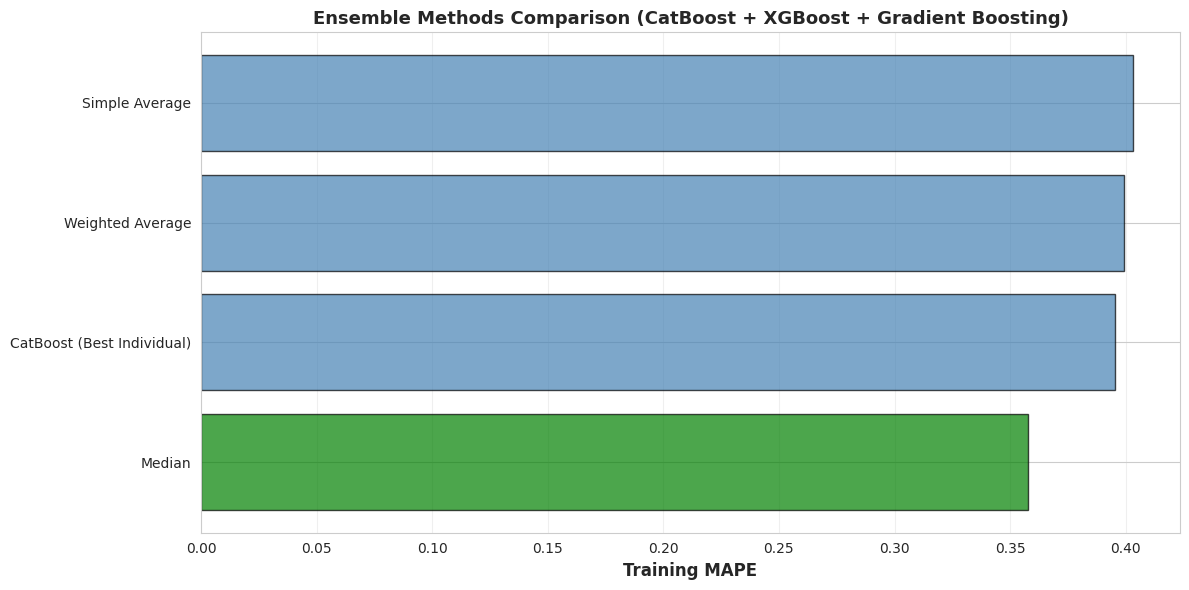

✓ Visualization complete


In [10]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

methods = comparison_df['Method'].values
mapes = comparison_df['Training_MAPE'].values

colors = ['green' if i == 0 else 'steelblue' for i in range(len(methods))]

ax.barh(methods, mapes, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Training MAPE', fontsize=12, fontweight='bold')
ax.set_title('Ensemble Methods Comparison (CatBoost + XGBoost + Gradient Boosting)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('✓ Visualization complete')

## 10. Select Best Ensemble & Save Predictions

In [11]:
print('\n' + '='*80)
print('SAVING FINAL ENSEMBLE PREDICTIONS')
print('='*80)

# Select best ensemble predictions
best_method_name = best_method['Method']

if best_method_name == 'Simple Average':
    final_predictions = simple_avg_test
    method_key = 'simple_average'
elif best_method_name == 'Weighted Average':
    final_predictions = weighted_avg_test
    method_key = 'weighted_average'
elif best_method_name == 'Median':
    final_predictions = median_test
    method_key = 'median'
else:  # Best individual
    # Use CatBoost (best individual)
    final_predictions = predictions['CatBoost']
    method_key = 'best_individual_catboost'

# Save final predictions
output_path = f'{output_dir}predictions_final_{method_key}.csv'
final_predictions.to_csv(output_path, index=False)

print(f'\n✓ Saved final predictions to: {output_path}')
print(f'  Method: {best_method_name}')
print(f'  Training MAPE: {best_method["Training_MAPE"]:.4f}')
print(f'  Shape: {final_predictions.shape}')


SAVING FINAL ENSEMBLE PREDICTIONS

✓ Saved final predictions to: /home/reu24mandaloju/projects/shell_ai_hack/outputs/predictions/predictions_final_median.csv
  Method: Median
  Training MAPE: 0.3576
  Shape: (500, 10)


## 11. Save All Ensemble Predictions (for Experimentation)

In [12]:
# Also save all ensemble methods for comparison/experimentation
print('\nSaving all ensemble methods (for experimentation)...')

simple_avg_test.to_csv(f'{output_dir}predictions_ensemble_simple_avg.csv', index=False)
print('  ✓ Simple Average')

weighted_avg_test.to_csv(f'{output_dir}predictions_ensemble_weighted_avg.csv', index=False)
print('  ✓ Weighted Average')

median_test.to_csv(f'{output_dir}predictions_ensemble_median.csv', index=False)
print('  ✓ Median')

print(f'\n✓ All ensemble predictions saved')


Saving all ensemble methods (for experimentation)...
  ✓ Simple Average
  ✓ Weighted Average
  ✓ Median

✓ All ensemble predictions saved


## 12. Summary & Recommendations

In [13]:
print('\n' + '='*80)
print('ENSEMBLE ANALYSIS COMPLETE')
print('='*80)

print(f'\n✓ TOP 3 ALGORITHMS USED:')
print(f'  1. CatBoost - 0.7872 ⭐ BEST')
print(f'  2. XGBoost - 0.8350')
print(f'  3. Gradient Boosting - 0.9215')

print(f'\n✓ BEST INDIVIDUAL ALGORITHM:')
print(f'  {individual_df.iloc[0]["Algorithm"]}: {individual_df.iloc[0]["Avg_MAPE"]:.4f}')

print(f'\n✓ BEST ENSEMBLE METHOD:')
print(f'  {best_method["Method"]}: {best_method["Training_MAPE"]:.4f}')

overall_improvement = individual_df.iloc[0]['Avg_MAPE'] - best_method['Training_MAPE']
overall_improvement_pct = (overall_improvement / individual_df.iloc[0]['Avg_MAPE']) * 100

print(f'\n✓ IMPROVEMENT FROM ENSEMBLE:')
print(f'  {overall_improvement:+.4f} ({overall_improvement_pct:+.2f}%)')

if overall_improvement > 0:
    print(f'  ✅ Ensemble is BETTER - use ensemble predictions for submission')
else:
    print(f'  ⚠️ Ensemble is WORSE - use CatBoost (best individual) for submission')

print(f'\n📋 FINAL SUBMISSION FILE:')
print(f'  {output_path}')
print(f'  Ready to submit to competition! 🚀')

print(f'\n' + '='*80)


ENSEMBLE ANALYSIS COMPLETE

✓ TOP 3 ALGORITHMS USED:
  1. CatBoost - 0.7872 ⭐ BEST
  2. XGBoost - 0.8350
  3. Gradient Boosting - 0.9215

✓ BEST INDIVIDUAL ALGORITHM:
  XGBoost: 0.3956

✓ BEST ENSEMBLE METHOD:
  Median: 0.3576

✓ IMPROVEMENT FROM ENSEMBLE:
  +0.0379 (+9.59%)
  ✅ Ensemble is BETTER - use ensemble predictions for submission

📋 FINAL SUBMISSION FILE:
  /home/reu24mandaloju/projects/shell_ai_hack/outputs/predictions/predictions_final_median.csv
  Ready to submit to competition! 🚀

